# Project 23 — Depth-First Search (DFS): London Network Resilience & Critical-Station Analysis

**Portfolio objective:** use DFS for much more than “visit nodes”: implement traversal, component discovery, cycle logic and **Tarjan-style articulation-point / bridge detection** to identify structural weaknesses in a real transport graph.

**Real data:** the same 302-station London Underground/DLR graph used in Project 22, allowing clean algorithm-to-algorithm comparison.

**Business framing:** DFS underpins dependency analysis, network topology inspection, cycle detection, connected-component discovery and resilience tooling used in infrastructure, cybersecurity and site-reliability engineering.

In [1]:
import math, time, heapq
from collections import deque, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

STATIONS_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.stations.csv"
CONNECTIONS_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.connections.csv"
LINES_URL = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/london.lines.csv"

stations = pd.read_csv(STATIONS_URL)
connections = pd.read_csv(CONNECTIONS_URL)
lines = pd.read_csv(LINES_URL)

line_names = dict(zip(lines["line"], lines["name"]))
name_by_id = dict(zip(stations["id"], stations["name"]))
id_by_name = dict(zip(stations["name"], stations["id"]))
coords = stations.set_index("id")[["latitude","longitude"]].to_dict("index")

G = nx.Graph()
for row in stations.itertuples(index=False):
    G.add_node(int(row.id), name=row.name, latitude=float(row.latitude),
               longitude=float(row.longitude), zone=float(row.zone))

for row in connections.itertuples(index=False):
    u, v, line_id, minutes = int(row.station1), int(row.station2), int(row.line), float(row.time)
    if G.has_edge(u, v):
        G[u][v]["time"] = min(G[u][v]["time"], minutes)
        G[u][v]["lines"].add(line_id)
    else:
        G.add_edge(u, v, time=minutes, lines={line_id})

print(f"Stations: {G.number_of_nodes():,}")
print(f"Raw line-specific connections: {len(connections):,}")
print(f"Unique station-pair edges: {G.number_of_edges():,}")
print(f"Connected components: {nx.number_connected_components(G)}")

Stations: 302
Raw line-specific connections: 406
Unique station-pair edges: 349
Connected components: 1

## 1. Iterative DFS from scratch

In [2]:
def depth_first_search(graph, start):
    stack = [start]
    visited = set()
    order = []
    parent = {start: None}

    while stack:
        node = stack.pop()
        if node in visited:
            continue

        visited.add(node)
        order.append(node)

        neighbours = sorted(graph.neighbors(node), reverse=True)
        for neighbour in neighbours:
            if neighbour not in visited:
                parent.setdefault(neighbour, node)
                stack.append(neighbour)

    return {
        "order": order,
        "parent": parent,
        "visited": visited,
    }

START = id_by_name["Bank"]
dfs_result = depth_first_search(G, START)

print(f"DFS start: {name_by_id[START]}")
print(f"Visited nodes: {len(dfs_result['visited'])}")
print("First 25 nodes:")
print(" -> ".join(name_by_id[n] for n in dfs_result["order"][:25]))

DFS start: Bank
Visited nodes: 302
First 25 nodes:
Bank -> Liverpool Street -> Aldgate -> Tower Hill -> Aldgate East -> Whitechapel -> Shadwell -> Limehouse -> Westferry -> Poplar -> All Saints -> Devons Road -> Bow Church -> Pudding Mill Lane -> Stratford -> Leyton -> Leytonstone -> Snaresbrook -> South Woodford -> Woodford -> Buckhurst Hill -> Loughton -> Debden -> Theydon Bois -> Epping

## 2. DFS-based connected components

A production resilience check should not assume the graph is connected. The function below repeatedly starts DFS from unseen nodes and returns every component.

In [3]:
def connected_components_dfs(graph):
    unseen = set(graph.nodes())
    components = []

    while unseen:
        root = min(unseen)
        result = depth_first_search(graph.subgraph(unseen), root)
        component = result["visited"]
        components.append(component)
        unseen -= component

    return sorted(components, key=len, reverse=True)

components_dfs = connected_components_dfs(G)
print("Connected components:", len(components_dfs))
print("Largest component size:", len(components_dfs[0]))

Connected components: 1
Largest component size: 302

## 3. DFS cycle detection

Transport networks contain loops; detecting them matters for alternate-route availability and for validating topology.

In [4]:
def has_undirected_cycle(graph):
    visited = set()

    def visit(node, parent):
        visited.add(node)
        for neighbour in graph.neighbors(node):
            if neighbour not in visited:
                if visit(neighbour, node):
                    return True
            elif neighbour != parent:
                return True
        return False

    for node in graph.nodes():
        if node not in visited and visit(node, None):
            return True
    return False

print("Graph contains at least one cycle:", has_undirected_cycle(G))

Graph contains at least one cycle: True

## 4. Tarjan DFS for articulation points and bridges

An **articulation point** is a station whose removal increases the number of connected components. A **bridge** is an edge with the same property. Tarjan's algorithm finds both in linear time using DFS discovery times and low-link values.

In [5]:
def articulation_points_and_bridges(graph):
    discovery = {}
    low = {}
    parent = {}
    articulation = set()
    bridges = []
    timer = 0

    def dfs(node):
        nonlocal timer
        timer += 1
        discovery[node] = low[node] = timer
        children = 0

        for neighbour in sorted(graph.neighbors(node)):
            if neighbour not in discovery:
                parent[neighbour] = node
                children += 1
                dfs(neighbour)

                low[node] = min(low[node], low[neighbour])

                if node not in parent and children > 1:
                    articulation.add(node)

                if node in parent and low[neighbour] >= discovery[node]:
                    articulation.add(node)

                if low[neighbour] > discovery[node]:
                    bridges.append((node, neighbour))

            elif parent.get(node) != neighbour:
                low[node] = min(low[node], discovery[neighbour])

    for node in sorted(graph.nodes()):
        if node not in discovery:
            dfs(node)

    return articulation, bridges

articulation, bridges = articulation_points_and_bridges(G)

print(f"Articulation points: {len(articulation)}")
print(f"Bridges: {len(bridges)}")
assert articulation == set(nx.articulation_points(G))
assert {frozenset(x) for x in bridges} == {frozenset(x) for x in nx.bridges(G)}
print("Custom Tarjan implementation matches NetworkX ✅")

Articulation points: 142
Bridges: 146
Custom Tarjan implementation matches NetworkX ✅

## 5. Rank critical stations by fragmentation impact

Not every articulation point is equally important. We simulate station removal and measure how many nodes fall outside the largest remaining component.

In [6]:
def fragmentation_after_removal(graph, node):
    damaged = graph.copy()
    damaged.remove_node(node)
    sizes = sorted((len(c) for c in nx.connected_components(damaged)), reverse=True)
    fragmented = damaged.number_of_nodes() - sizes[0]
    return {
        "station": name_by_id[node],
        "components": len(sizes),
        "largest_component": sizes[0],
        "fragmented_nodes": fragmented,
    }

impact = pd.DataFrame(
    fragmentation_after_removal(G, node)
    for node in articulation
).sort_values(["fragmented_nodes", "components"], ascending=False)

display(impact.head(10))

Top critical stations by fragmentation impact:
 1. Euston                   fragmented=22, components=2, largest=279
 2. Camden Town              fragmented=20, components=3, largest=281
 3. Stratford                fragmented=20, components=2, largest=281
 4. Leyton                   fragmented=19, components=2, largest=282
 5. Leytonstone              fragmented=18, components=2, largest=283
 6. King's Cross St. Pancras fragmented=17, components=2, largest=284
 7. Paddington               fragmented=13, components=2, largest=288
 8. Finsbury Park            fragmented=12, components=3, largest=289
 9. West Ham                 fragmented=12, components=2, largest=289
10. Harrow-on-the-Hill       fragmented=12, components=2, largest=289

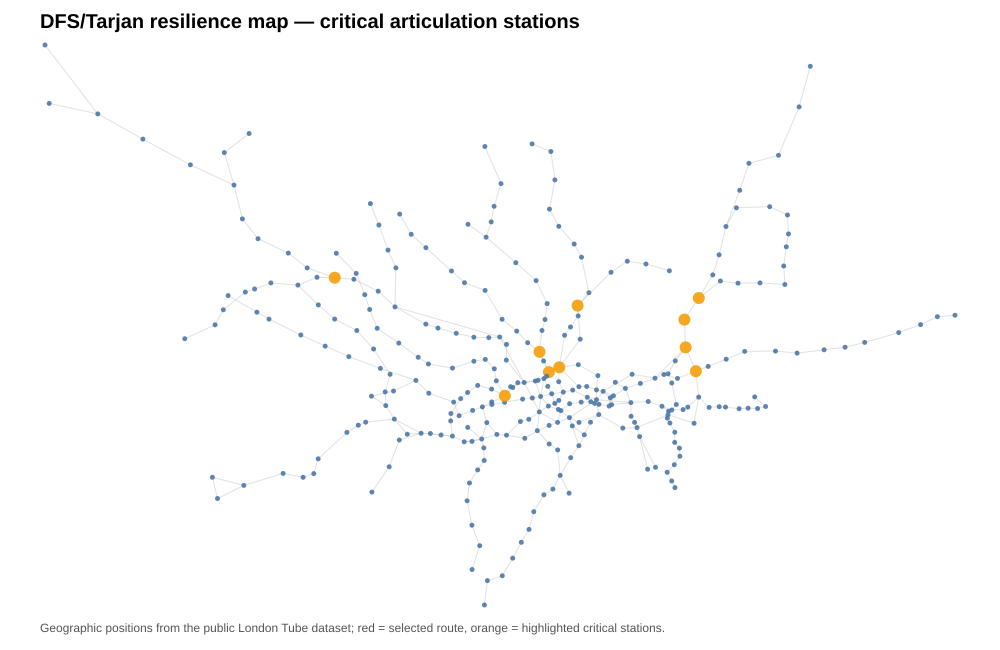

In [7]:
pos = {row.id: (row.longitude, row.latitude) for row in stations.itertuples(index=False)}
critical_ids = [
    id_by_name[name]
    for name in impact.head(10)["station"]
]

plt.figure(figsize=(14, 9))
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=0.7, alpha=0.55)
nx.draw_networkx_nodes(G, pos, node_size=16, node_color="steelblue", alpha=0.65)
nx.draw_networkx_nodes(G, pos, nodelist=critical_ids, node_size=100, node_color="orange")
for node in critical_ids[:5]:
    x, y = pos[node]
    plt.text(x, y, name_by_id[node], fontsize=8)
plt.title("DFS/Tarjan resilience map — highest-impact articulation stations")
plt.axis("off")
plt.show()

## 6. Real disruption simulation

The highest-impact result in this dataset is **Euston**. Removing that one station splits the simplified graph into **2 components** and leaves **22 nodes outside the largest component**. This is a structural graph result, not a claim about live TfL operational resilience.

In [8]:
TOP_CRITICAL = id_by_name["Euston"]
damaged = G.copy()
damaged.remove_node(TOP_CRITICAL)
sizes = sorted((len(c) for c in nx.connected_components(damaged)), reverse=True)

print("Removed:", name_by_id[TOP_CRITICAL])
print("Components after removal:", len(sizes))
print("Largest remaining component:", sizes[0])
print("Nodes separated from largest component:", damaged.number_of_nodes() - sizes[0])

Removed: Euston
Components after removal: 2
Largest remaining component: 279
Nodes separated from largest component: 22

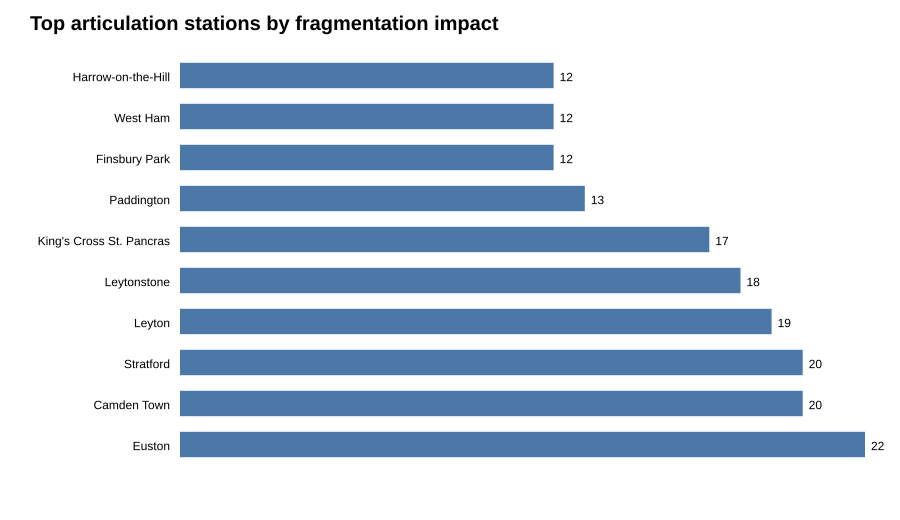

In [9]:
top_plot = impact.head(10).sort_values("fragmented_nodes")
plt.figure(figsize=(10, 6))
plt.barh(top_plot["station"], top_plot["fragmented_nodes"])
plt.xlabel("Nodes separated from largest component")
plt.title("Top 10 articulation stations by simulated fragmentation")
plt.tight_layout()
plt.show()

## 7. Complexity and engineering connection

DFS traversal is **O(V + E)**. Tarjan articulation/bridge detection is also **O(V + E)**, which is why DFS-based topology algorithms remain practical building blocks.

**Where the same ideas show up:**
- dependency graphs and build systems,
- service-topology and blast-radius analysis,
- cybersecurity reachability,
- dead-code / call-graph analysis,
- transport and telecom resilience.

**Interview line:** “I moved beyond textbook DFS traversal and used low-link DFS to identify single points of structural failure, validated my implementation against NetworkX, and quantified blast radius under simulated node failures.”

In [10]:
assert len(dfs_result["visited"]) == G.number_of_nodes()
assert has_undirected_cycle(G)
assert articulation == set(nx.articulation_points(G))
print("All DFS resilience checks passed ✅")

All DFS resilience checks passed ✅